60 rows in the sample:
press_team        ATM  BAR
label_source              
detected_episode   15   15
hard_negative      21    9

judged windows: median 3.0 s (min 0.5, max 6.0); clips are 5.0 s on average

video: 1920x1080, 25.00 fps, 70,327 frames; the sample needs frames 2,117 to 68,361 (inside the video)


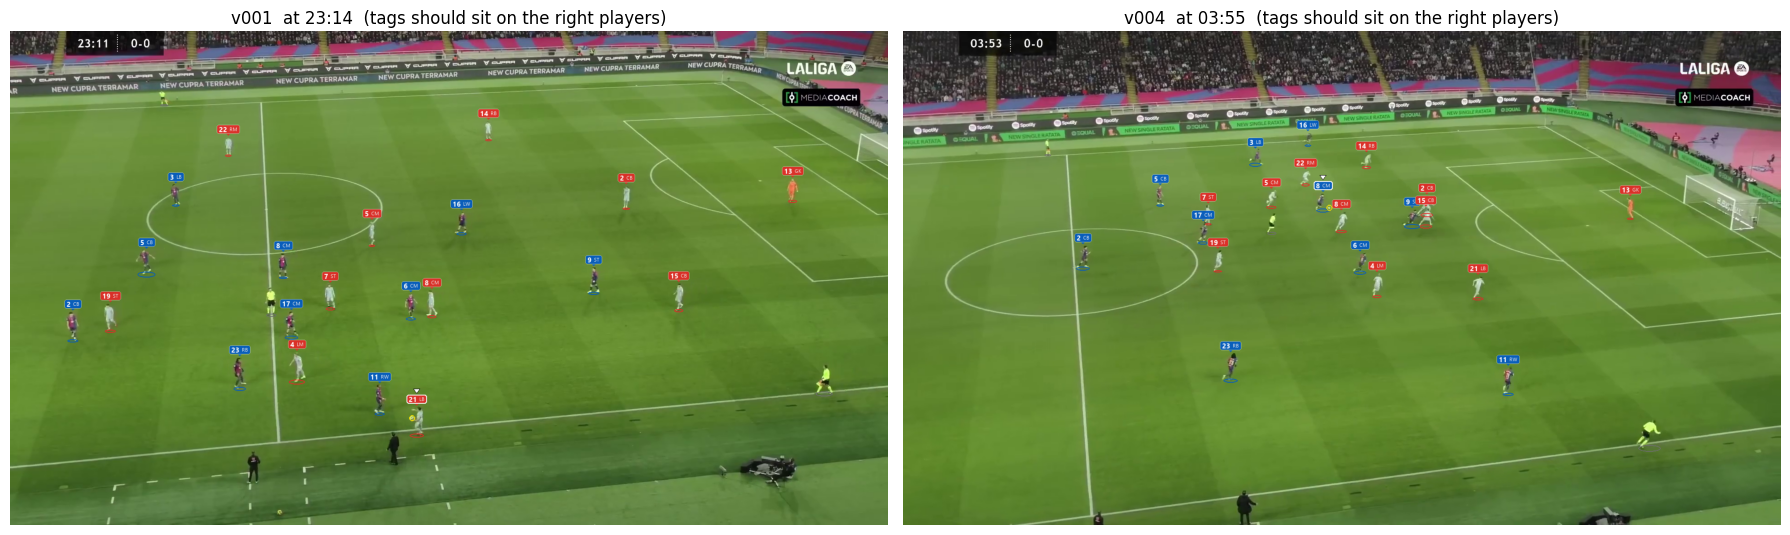


next cell: renders all 60 clips (about 10 minutes) and builds the review page.


In [1]:
# ================================================================== EPISODE VALIDATION NOTEBOOK - cell 1: setup, the blinded sample, and a look at two frames
# Goal: check by eye how many of the detected pressure episodes are real presses (precision), and how many "near miss" moments were real presses the detector missed.
# The clips are BLINDED: the video shows only tags, the carrier marker and the ball, never the detector's answer, and the order is shuffled.
import json, re, shutil, subprocess, time
import numpy as np
import pandas as pd
import cv2
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont

BASE = Path("C:/Users/user/Desktop/Football_cv_project/football-pipeline (1)/project")
CACHE = BASE / "barca_atletico_first_half" / "new_cache"
PLAYER_PATH, BALL_PATH = CACHE / "player_frame_table_named.parquet", CACHE / "ball_frame_table_named.parquet"
VIDEO_PATH = BASE / "barca_atletico_first_half" / "clip.mkv"
PRESS_DIR = BASE / "new" / "press"
INPUT_DIR = PRESS_DIR / "buildup_output" / "pressure_stats_input"                       # tables exported by the analysis notebook
SAMPLE_PATH = PRESS_DIR / "pressure_stats_output" / "episode_validation_sample.csv"     # written by cell 7 of the stats notebook
OUT_DIR = PRESS_DIR / "validation"; (OUT_DIR / "clips").mkdir(parents=True, exist_ok=True)

FRAME_OFFSET = 0          # video frame = table frame + FRAME_OFFSET (set it from the clip review if boxes were shifted)
PAD_SEC = 1.0             # context shown before and after the part to judge
MAX_JUDGE_SEC = 6.0       # a long episode is judged on its first 6 s only
NEG_JUDGE_SEC = 3.0       # length of the judged window for a "hard negative"
SEED = 7
meta = json.load(open(INPUT_DIR / "meta.json")); FPS = meta["fps"]; TEAM_NAMES = {int(k): v for k, v in meta["team_names"].items()}
F = lambda s: int(round(s * FPS))
mmss = lambda f: f"{int(f / FPS) // 60:02d}:{int(f / FPS) % 60:02d}"

# ------------------------------------------------------------------ the sample and the context tables
sample = pd.read_csv(SAMPLE_PATH)
roster = pd.read_parquet(INPUT_DIR / "roster.parquet"); frames_tbl = pd.read_parquet(INPUT_DIR / "frames.parquet")
POS_OF = dict(zip(roster.track_id.astype(int), roster.position)); NUM_OF = dict(zip(roster.track_id.astype(int), roster.number))
print(f"{len(sample)} rows in the sample:\n{sample.groupby(['label_source', 'press_team']).size().unstack(fill_value=0).to_string()}")

# ------------------------------------------------------------------ the blinded key: one anonymous id per clip, shuffled; the true source stays in the key file only
key = sample.copy().sample(frac=1, random_state=SEED).reset_index(drop=True)
key["vid"] = [f"v{i + 1:03d}" for i in range(len(key))]
key["judge_start"] = key.start_frame.astype(int)
key["judge_end"] = np.where(key.label_source == "detected_episode", np.minimum(key.end_frame, key.start_frame + F(MAX_JUDGE_SEC)), key.start_frame + F(NEG_JUDGE_SEC)).astype(int)
key["clip_start"] = (key.judge_start - F(PAD_SEC)).clip(lower=0); key["clip_end"] = key.judge_end + F(PAD_SEC)
fi = frames_tbl.set_index("frame_idx").sort_index()
def window_stats(a, b):
    w = fi.loc[a:b]
    return pd.Series(dict(min_dist_m=w.min_dist.min(), mean_n_near=w.n_near.mean(), max_pressers=w.n_pressing.max(), pressed_share=w.under_pressure.mean(),
                          carrier_share=(w.src == "carrier").mean(), x_att_start=w.x_att.iloc[0] if len(w) else np.nan, n_frames=len(w)))
key = pd.concat([key, key.apply(lambda r: window_stats(r.judge_start, r.judge_end), axis=1)], axis=1)
key["judge_sec"] = (key.judge_end - key.judge_start) / FPS
key.to_csv(OUT_DIR / "episode_validation_key.csv", index=False)            # keep this file out of sight while labelling
print(f"\njudged windows: median {key.judge_sec.median():.1f} s (min {key.judge_sec.min():.1f}, max {key.judge_sec.max():.1f}); clips are {((key.clip_end - key.clip_start) / FPS).median():.1f} s on average")

# ------------------------------------------------------------------ annotation: tags + carrier marker + small yellow ball (same look as the clips, but no pressure information)
TEAM_RGB = {0: (230, 40, 40), 1: (0, 90, 200)}
def _font(size, bold=False):
    for c in (["C:/Windows/Fonts/segoeuib.ttf", "C:/Windows/Fonts/arialbd.ttf"] if bold else ["C:/Windows/Fonts/segoeui.ttf", "C:/Windows/Fonts/arial.ttf"]) + \
             [str(Path(matplotlib.get_data_path()) / "fonts" / "ttf" / ("DejaVuSans-Bold.ttf" if bold else "DejaVuSans.ttf"))]:
        if Path(c).exists():
            return ImageFont.truetype(c, size)
    return ImageFont.load_default()

def smooth_boxes(b, win=5):
    cols = ["x1", "y1", "x2", "y2", "foot_px_x", "foot_px_y"]; b = b.sort_values(["track_id", "frame_idx"]).copy()
    seg = (b.groupby("track_id")["frame_idx"].diff() != 1).cumsum()
    for c in cols:
        b[c] = b.groupby(["track_id", seg])[c].transform(lambda s: s.rolling(win, center=True, min_periods=1).mean())
    return b

def draw_tags(img, players, ball_xy, carrier_id):
    H_, W_ = img.shape[:2]; s = H_ / 1080; nf, pf_ = _font(max(12, int(15 * s)), True), _font(max(9, int(11 * s)), False)
    base = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)).convert("RGBA"); ov = Image.new("RGBA", base.size, (0, 0, 0, 0)); dr = ImageDraw.Draw(ov)
    pad_x, pad_y, gap = int(5 * s), int(2 * s), int(6 * s); items = []
    for r in players.itertuples():
        if pd.isna(r.x1) or pd.isna(r.foot_px_x):
            continue
        ref = (r.role == "referee"); col = (110, 110, 110) if ref else TEAM_RGB.get(int(r.team), (128, 128, 128))
        it = dict(r=r, ref=ref, col=col, fx=int(r.foot_px_x), fy=int(r.foot_px_y), w=max(int(r.x2 - r.x1), 16))
        if not ref:
            num = str(int(r.number)) if pd.notna(r.number) else "?"; pos = POS_OF.get(int(r.track_id), "")
            nw = dr.textlength(num, font=nf); pw = dr.textlength(pos, font=pf_) if pos else 0
            it.update(num=num, pos=pos, nw=nw, lh=int(nf.size + 2 * pad_y), lw=int(nw + (pw + 5 * s if pos else 0) + 2 * pad_x), cx=int((r.x1 + r.x2) / 2), top=int(r.y1))
        items.append(it)
    for it in sorted(items, key=lambda i: i["fy"]):                                  # far -> near
        col = it["col"]
        dr.ellipse([it["fx"] - int(it["w"] * .45), it["fy"] - int(it["w"] * .14), it["fx"] + int(it["w"] * .45), it["fy"] + int(it["w"] * .14)], outline=col + (225,), width=max(1, int(2 * s)))
        if it["ref"]:
            continue
        lw, lh = it["lw"], it["lh"]; x0 = int(np.clip(it["cx"] - lw // 2, 2, W_ - lw - 2)); y0 = max(it["top"] - lh - gap, 2); is_car = pd.notna(carrier_id) and it["r"].track_id == carrier_id
        dr.polygon([(x0 + lw // 2 - int(4 * s), y0 + lh), (x0 + lw // 2 + int(4 * s), y0 + lh), (x0 + lw // 2, y0 + lh + int(4 * s))], fill=col + (232,))
        dr.rounded_rectangle([x0, y0, x0 + lw, y0 + lh], radius=int(lh * .28), fill=col + (232,), outline=(255, 255, 255, 240) if is_car else (255, 255, 255, 120), width=2 if is_car else 1)
        dr.text((x0 + pad_x, y0 + lh // 2), it["num"], font=nf, fill=(255, 255, 255, 255), anchor="lm")
        if it["pos"]:
            dr.text((x0 + pad_x + it["nw"] + 5 * s, y0 + lh // 2), it["pos"], font=pf_, fill=(238, 238, 238, 255), anchor="lm")
        if is_car:
            mx, ty = x0 + lw // 2, y0 - int(3 * s)
            dr.polygon([(mx - int(7 * s), ty - int(10 * s)), (mx + int(7 * s), ty - int(10 * s)), (mx, ty)], fill=(255, 255, 255, 255), outline=(0, 0, 0, 255))
    if ball_xy is not None:
        bx, by, br = int(ball_xy[0]), int(ball_xy[1]), max(4, int(6 * s)); dr.ellipse([bx - br, by - br, bx + br, by + br], outline=(255, 230, 0, 255), width=max(2, int(2 * s)))
    img[:] = cv2.cvtColor(np.array(Image.alpha_composite(base, ov).convert("RGB")), cv2.COLOR_RGB2BGR)

# ------------------------------------------------------------------ checks + a look at two frames
CALIB = ["frame_idx", "track_id", "role", "team", "number", "x1", "y1", "x2", "y2", "foot_px_x", "foot_px_y"]
cap = cv2.VideoCapture(str(VIDEO_PATH)); assert cap.isOpened(), f"cannot open {VIDEO_PATH}"
n_vid = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)); fps_vid = cap.get(cv2.CAP_PROP_FPS); W_, H_ = int(cap.get(3)), int(cap.get(4))
print(f"\nvideo: {W_}x{H_}, {fps_vid:.2f} fps, {n_vid:,} frames; the sample needs frames {key.clip_start.min():,} to {key.clip_end.max():,} "
      f"({'inside the video' if key.clip_end.max() + FRAME_OFFSET < n_vid else 'OUTSIDE THE VIDEO - check FRAME_OFFSET'})")
if abs(fps_vid - FPS) > 0.1:
    print(f"WARNING: the video runs at {fps_vid:.2f} fps but the tables use {FPS}; clip times would drift")

bpx = pd.read_parquet(BALL_PATH, columns=["frame_idx", "ball_px_x", "ball_px_y", "carrier_track_id"]).set_index("frame_idx")
prev = key.groupby("label_source").head(1)                                          # one detected episode and one hard negative
fig, ax = plt.subplots(1, len(prev), figsize=(9 * len(prev), 5.6))
for a, r in zip(np.atleast_1d(ax), prev.itertuples()):
    f = int(r.judge_start); cap.set(cv2.CAP_PROP_POS_FRAMES, f + FRAME_OFFSET); ok, img = cap.read()
    pl = pd.read_parquet(PLAYER_PATH, columns=CALIB, filters=[("frame_idx", "==", f)])
    b = bpx.loc[f] if f in bpx.index else None
    draw_tags(img, pl, (b.ball_px_x, b.ball_px_y) if b is not None and pd.notna(b.ball_px_x) else None, b.carrier_track_id if b is not None else None)
    a.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); a.axis("off"); a.set_title(f"{r.vid}  at {mmss(f)}  (tags should sit on the right players)")
plt.tight_layout(); plt.savefig(OUT_DIR / "preview_two_frames.png", dpi=100); plt.show(); cap.release()
print("\nnext cell: renders all", len(key), "clips (about 10 minutes) and builds the review page.")